In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("indian_gold_loan_data.csv")
df

,Customer_ID,Name,Age,Occupation,Monthly_Income,Branch,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
0,CUST-1000,Abeer Srivastava,61,Daily Wage,117863,Edappally,90.20,20,638661.10,73.526610,469585.86,12,2,0
1,CUST-1001,Samarth Purohit,27,Professional,113700,Edappally,25.55,22,198932.30,64.773032,128854.48,9,1,0
2,CUST-1002,Devansh Bajwa,48,Small Business,30414,Thrissur-Town,129.29,18,824223.75,62.495063,515099.15,12,2,1
3,CUST-1003,Advik Srinivas,29,Daily Wage,61654,Palakkad-Main,139.08,22,1082876.88,61.376661,664633.67,3,0,0
4,CUST-1004,Darpan Dey,55,Small Business,118093,Edappally,6.96,22,54190.56,85.428911,46294.41,24,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST-10995,Omisha Saran,21,Daily Wage,142994,Thrissur-Town,69.19,22,538713.34,75.501611,406737.25,3,0,0
9996,CUST-10996,Madhavi Virk,35,Small Business,112793,Edappally,134.92,20,955301.06,84.298838,805307.69,12,1,1
9997,CUST-10997,Vedhika Loyal,46,Small Business,65917,Edappally,190.29,20,1347348.34,77.773465,1047879.49,24,2,1
9998,CUST-10998,Dakshesh Guha,26,Farmer,115230,Thrissur-Town,44.66,22,347722.76,87.425668,303998.95,24,2,1


# Dataset Details

In [4]:
print("===============================Dataset Details==========================================\n")
print(f"Shape : {df.shape[0]} Columns X {df.shape[1]} Rows")
print(f"Size : {df.size}")
print(f"Null Values : {df.isnull().sum().sum()}")
print(f"Dimensions : {df.ndim}")
print(f"Duplicate Values : {df.duplicated().sum()}\n")
print("===============================Data Types==========================================\n")
print(f" \n{df.dtypes}")

===============================Dataset Details==========================================

Shape : 10000 Columns X 14 Rows
Size : 140000
Null Values : 0
Dimensions : 2
Duplicate Values : 0

===============================Data Types==========================================

 
Customer_ID             str
Name                    str
Age                   int64
Occupation              str
Monthly_Income        int64
Branch                  str
Gold_Weight_g       float64
Gold_Purity           int64
Market_Value_INR    float64
LTV_Ratio           float64
Loan_Amount_INR     float64
Tenure_Months         int64
Past_Defaults         int64
Default_Status        int64
dtype: object


# Statistical Summary

In [5]:
df.describe()

,Age,Monthly_Income,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000
mean,45.614400,82707.828100,101.546248,21.049000,7.566319e+05,75.053628,5.679186e+05,10.784100,1.51240,0.452700
std,14.425572,39087.290194,56.658313,2.221462,4.314417e+05,8.658351,3.323291e+05,7.267074,1.12293,0.497783
min,21.000000,15027.000000,5.000000,18.000000,3.187500e+04,60.003438,2.102418e+04,3.000000,0.00000,0.000000
25%,33.000000,48350.500000,51.865000,20.000000,3.800696e+05,67.537018,2.833324e+05,6.000000,1.00000,0.000000
50%,46.000000,83596.500000,100.950000,22.000000,7.438491e+05,75.121375,5.535350e+05,9.000000,2.00000,0.000000
75%,58.000000,116639.750000,150.055000,24.000000,1.115131e+06,82.576615,8.236058e+05,12.000000,3.00000,1.000000
max,70.000000,149981.000000,199.970000,24.000000,1.698555e+06,89.998730,1.517331e+06,24.000000,3.00000,1.000000


# Feature Engineering

In [6]:
df=df.drop(columns=["Customer_ID","Name","Branch"])
df

,Age,Occupation,Monthly_Income,Gold_Weight_g,Gold_Purity,Market_Value_INR,LTV_Ratio,Loan_Amount_INR,Tenure_Months,Past_Defaults,Default_Status
0,61,Daily Wage,117863,90.20,20,638661.10,73.526610,469585.86,12,2,0
1,27,Professional,113700,25.55,22,198932.30,64.773032,128854.48,9,1,0
2,48,Small Business,30414,129.29,18,824223.75,62.495063,515099.15,12,2,1
3,29,Daily Wage,61654,139.08,22,1082876.88,61.376661,664633.67,3,0,0
4,55,Small Business,118093,6.96,22,54190.56,85.428911,46294.41,24,3,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,21,Daily Wage,142994,69.19,22,538713.34,75.501611,406737.25,3,0,0
9996,35,Small Business,112793,134.92,20,955301.06,84.298838,805307.69,12,1,1
9997,46,Small Business,65917,190.29,20,1347348.34,77.773465,1047879.49,24,2,1
9998,26,Farmer,115230,44.66,22,347722.76,87.425668,303998.95,24,2,1


In [7]:
df["Occupation"].value_counts()

Occupation
Farmer            2057
Small Business    2036
Professional      1992
Salaried          1984
Daily Wage        1931
Name: count, dtype: int64

In [8]:
# Fit the scaler on relevant numerical columns
scaler.fit(df[['Monthly_Income', 'Age', 'Gold_Weight_g', 'Tenure_Months', 'Past_Defaults']])

# Transform the columns
scaled_features = scaler.transform(df[['Monthly_Income', 'Age', 'Gold_Weight_g', 'Tenure_Months', 'Past_Defaults']])
df_scaled = pd.DataFrame(scaled_features, columns=['scaled_income', 'scaled_age', 'scaled_gold', 'scaled_tenure', 'scaled_defaults'])

# Get occupation score
occupation_map = {
    'Professional': 0.95,
    'Salaried': 0.85,
    'Small Business': 0.70,
    'Farmer': 0.60,
    'Daily Wage': 0.40
}

df['occ_score'] = df['Occupation'].map(occupation_map).fillna(0.55)
# Calculate credit score with weights and scale to 300-900
df['Credit_Score'] = (
    0.15 * df_scaled['scaled_income'] +
    0.15 * df_scaled['scaled_age'] +
    0.15 * df_scaled['scaled_gold'] +
    0.15 * df_scaled['scaled_tenure'] +
    0.15 * (1 - df_scaled['scaled_defaults']) +
    0.1 * occ_score
) * 600 + 300

# Round to nearest integer
df['Credit_Score'] = df['Credit_Score'].round().astype(int)
df

NameError: name 'scaler' is not defined

In [ ]:
df["Credit_Score"].describe()

count    10000.000000
mean       546.571400
std         67.275331
min        328.000000
25%        499.000000
50%        545.000000
75%        593.000000
max        780.000000
Name: Credit_Score, dtype: float64

# Visualization 

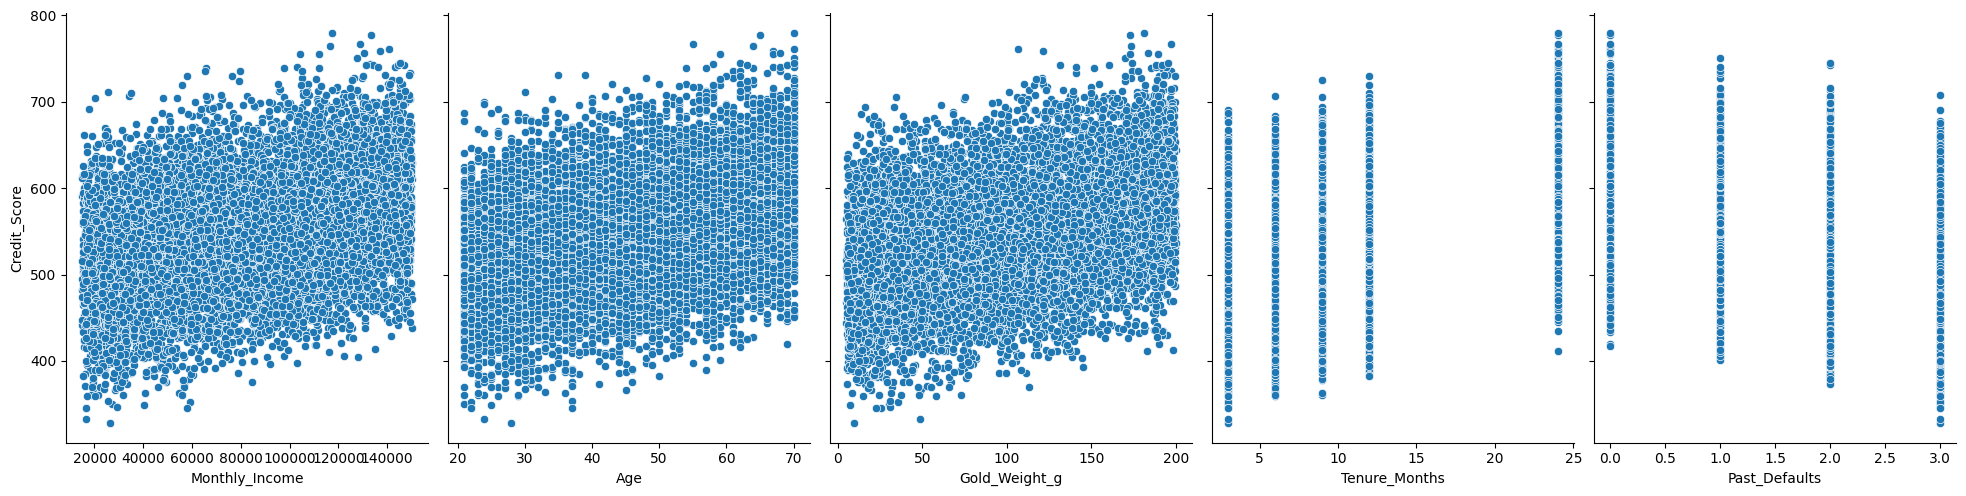

In [ ]:
sns.pairplot(df, x_vars=['Monthly_Income', 'Age', 'Gold_Weight_g', 'Tenure_Months', 'Past_Defaults'], y_vars='Credit_Score', height=5, aspect=0.8)
plt.show()

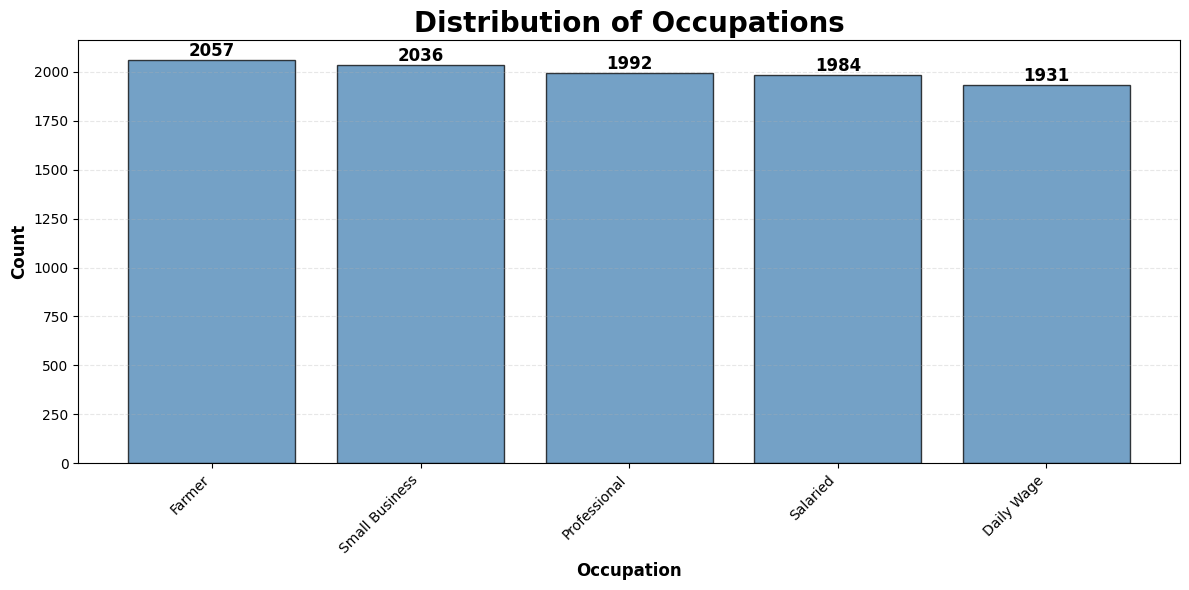

In [ ]:
plt.figure(figsize=(12, 6))
occupation_counts = df['Occupation'].value_counts()
bars = plt.bar(occupation_counts.index, occupation_counts.values, color='steelblue', edgecolor='black', alpha=0.75)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Occupation', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Occupations', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

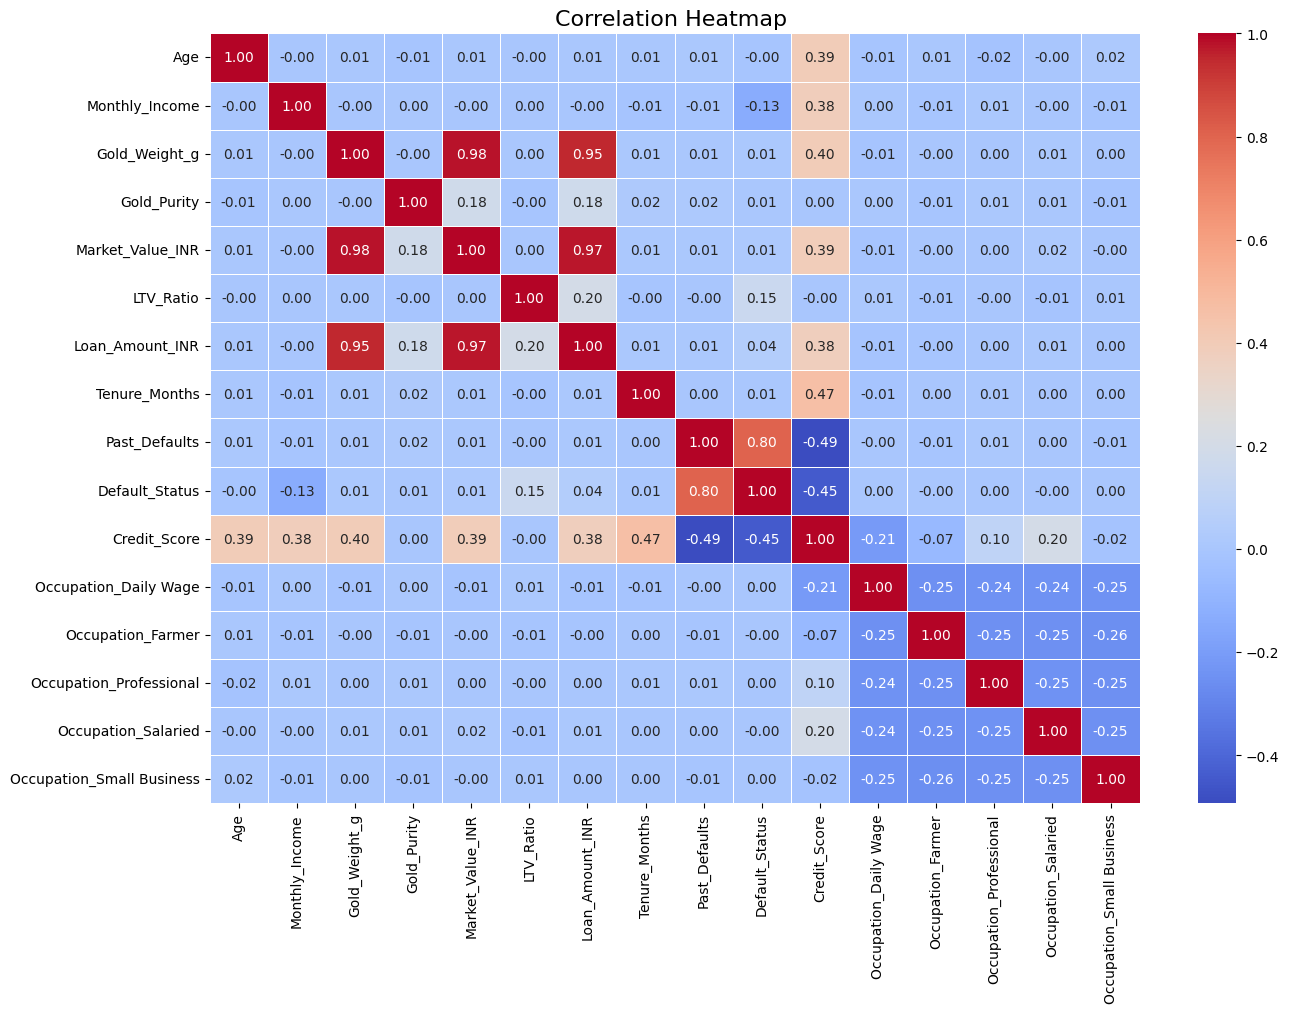

In [ ]:
# One-hot encode the 'Occupation' column
occupation_dummies = pd.get_dummies(df['Occupation'], prefix='Occupation')

# Combine with numerical columns
numerical_cols = ['Age', 'Monthly_Income', 'Gold_Weight_g', 'Gold_Purity', 'Market_Value_INR', 'LTV_Ratio', 'Loan_Amount_INR', 'Tenure_Months', 'Past_Defaults', 'Default_Status', 'Credit_Score']
df_for_corr = pd.concat([df[numerical_cols], occupation_dummies], axis=1)

# Compute correlation matrix
corr = df_for_corr.corr()

# Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap ', fontsize=16)
plt.show()

<Figure size 500x1500 with 0 Axes>

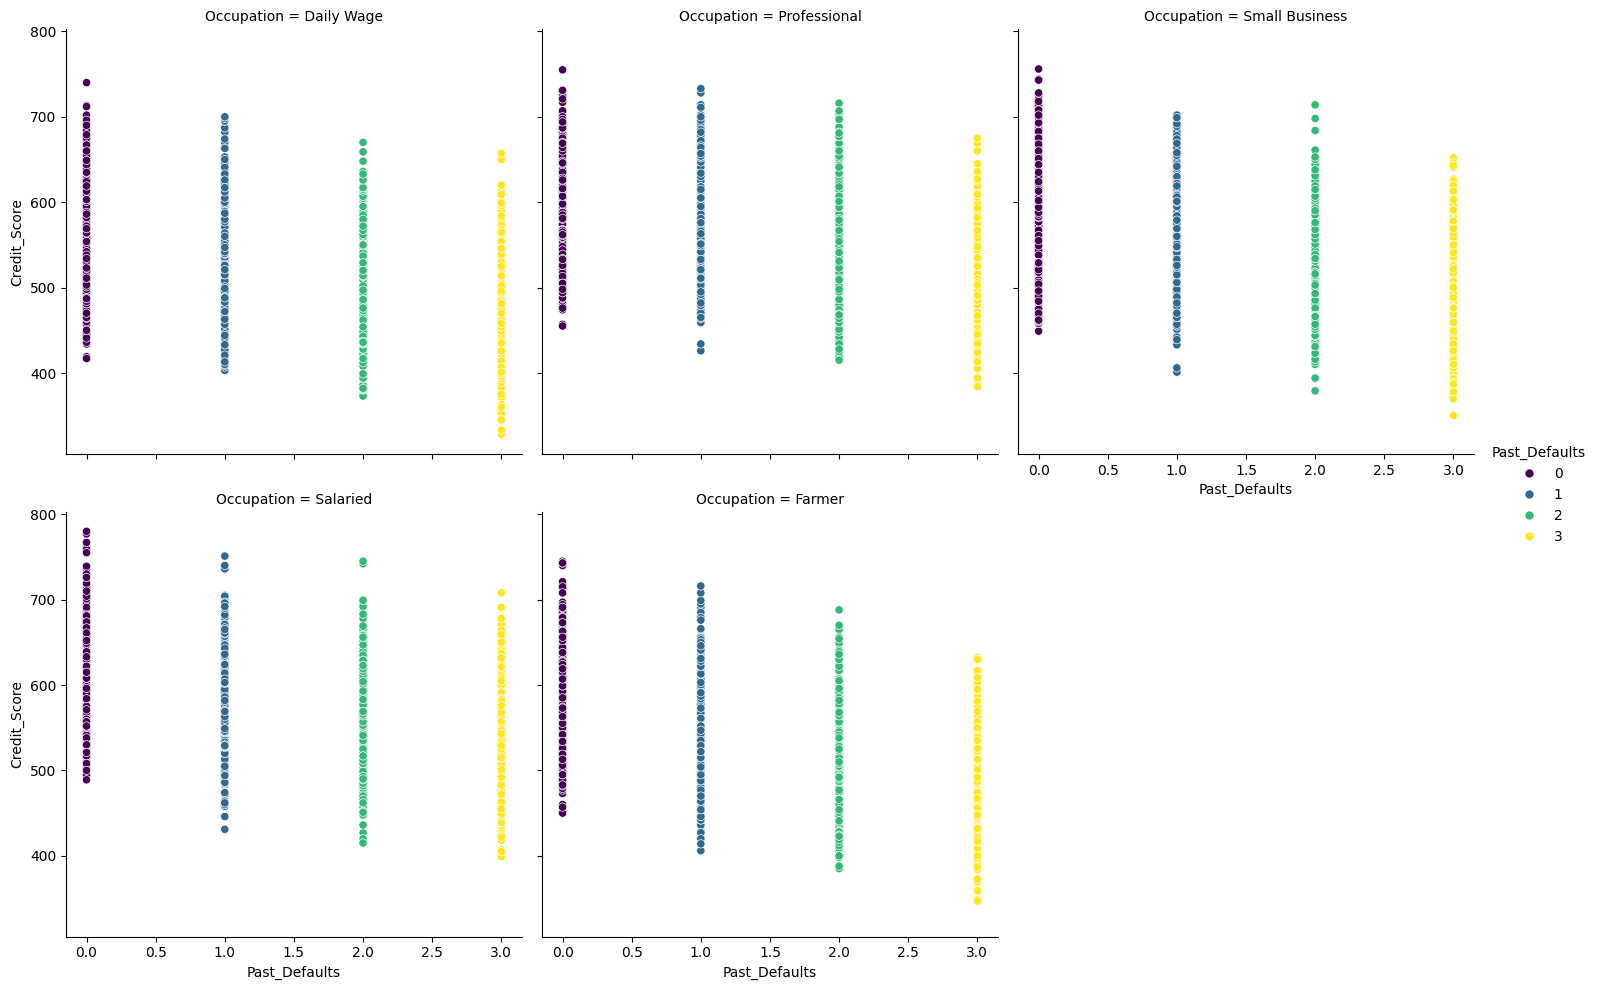

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a relplot with facets for each occupation, plotting Past_Defaults vs Credit_Score, colored by Past_Defaults
plt.figure(figsize=(5,15))
sns.relplot(data=df, x='Past_Defaults', y='Credit_Score', hue='Past_Defaults', col='Occupation', col_wrap=3, palette='viridis')
plt.show()

C:\Users\user'\AppData\Local\Temp\ipykernel_14420\3122555101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_income, x='Occupation', y='Monthly_Income', palette='viridis')


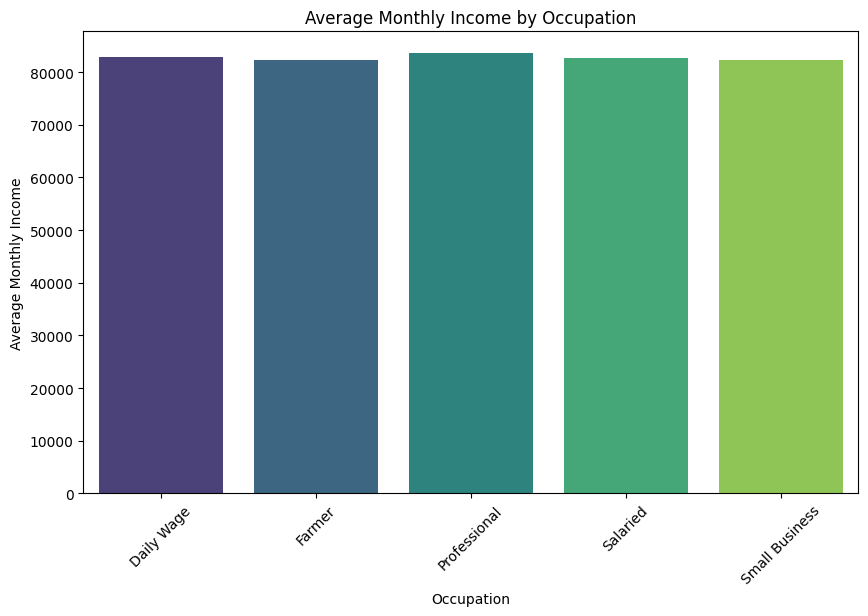

In [9]:
# Calculate average income per occupation
avg_income = df.groupby('Occupation')['Monthly_Income'].mean().reset_index()

# Plot the relation
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_income, x='Occupation', y='Monthly_Income', palette='viridis')
plt.title('Average Monthly Income by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45)
plt.show()